# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [9]:
# Import the libraries
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


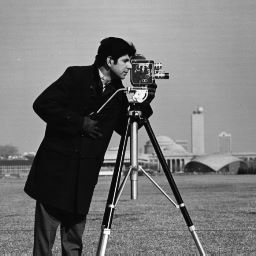

In [10]:
# ── Load image ────────────────────────────────────
image = Image.open("camera_man.jpg").convert("L")
display(image)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [11]:
# Get the size of the image
width, height = image.size

# scaling factors
cx, cy = 2, 2
new_width = int(width * cx)
new_height = int(height * cy)
print("Original size:", image.size)


Original size: (256, 256)


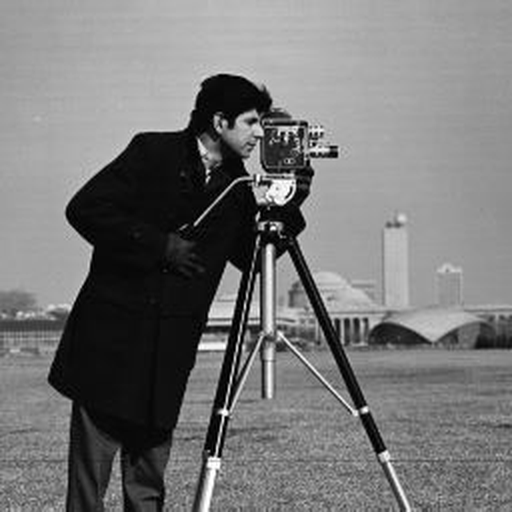

In [12]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
display(scaled_image)


In [27]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_scaled.jpg")
print("Original size:", image.size)
print("Scaled size:", scaled_image.size)


Original size: (256, 256)
Scaled size: (512, 512)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [14]:
# Non-uniform scale: cx = 2, cy = 1
cx, cy = 2, 1
non_uniform_size = (int(width * cx), int(height * cy))


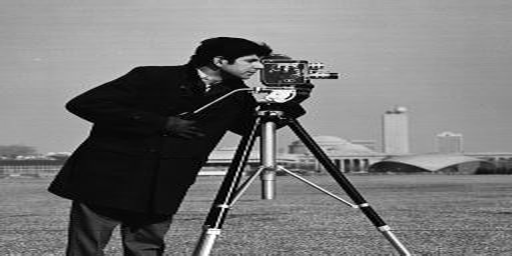

In [15]:
# Stretch horizontally only
non_uniform_image = image.resize(non_uniform_size, Image.Resampling.LANCZOS)
display(non_uniform_image)


In [28]:
# Save the non-uniformly scaled result
non_uniform_image.save("task1_non_uniform_scaled.jpg")
print("Original size:", image.size)
print("Non-uniform size:", non_uniform_image.size)


Original size: (256, 256)
Non-uniform size: (512, 256)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (256, 256)
Rotated size: (350, 350)


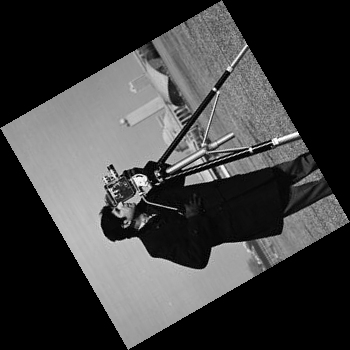

In [32]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = image.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)
rotated_image.save("task2_rotated.jpg")
print("Original size:", image.size)
print("Rotated size:", rotated_image.size)
display(rotated_image)


### 3. Shear

In [18]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size
print("Image dimensions:", width, "x", height)


Image dimensions: 256 x 256


In [19]:
# -- d. define the shear matrix ──────────────────────────
# X-axis shear with factor 0.5
shx = 0.5
shy = 0.0

# Make the canvas wide enough for the slanted image
new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

# Translation prevents negative coordinates when using a negative shear
tx = max(0, -shx * height)
ty = max(0, -shy * width)


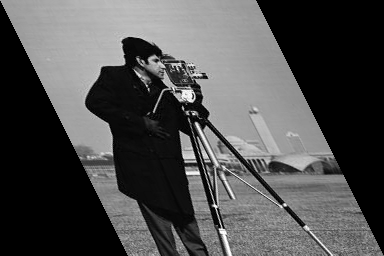

In [20]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL transform() expects the inverse mapping.
# Forward X shear: x' = x + shx*y  -> inverse: x = x' - shx*y'
sheared_image = image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, tx, -shy, 1, ty),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)
display(sheared_image)


In [21]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared_image.save("task1_3_sheared.jpg")
print("Original size:", image.size)
print("Sheared size:", sheared_image.size)


Original size: (256, 256)
Sheared size: (384, 256)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

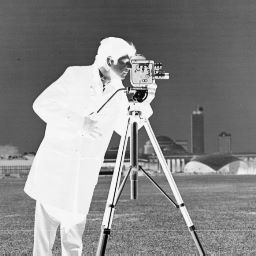

In [22]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(image, dtype=np.uint8)
negative_arr = 255 - arr
negative_numpy = Image.fromarray(negative_arr)
negative_numpy.save("task2_1_negative_numpy.jpg")
display(negative_numpy)


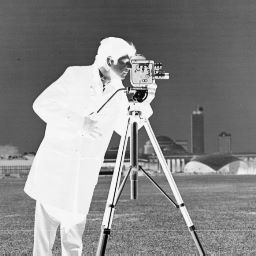

In [23]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(image)
negative_pil.save("task2_1_negative_pil.jpg")
display(negative_pil)


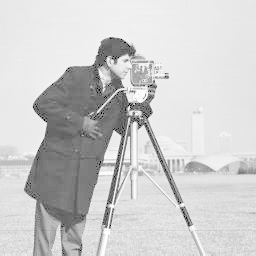

In [24]:
# ── 2. Log transformation ──────────────────────────
# s = c · log(1 + r)
# c = 255 / log(1 + 255)
c = 255 / np.log1p(255)

# Use float before adding 1 to avoid uint8 overflow at 255
arr_float = np.array(image, dtype=np.float32)
log_arr = c * np.log1p(arr_float)
log_arr = np.clip(log_arr, 0, 255).astype(np.uint8)
log_transformed = Image.fromarray(log_arr)
log_transformed.save("task2_2_log.jpg")
display(log_transformed)


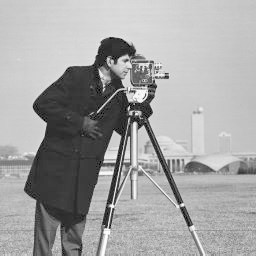

In [25]:
# ── 3. Power-law / Gamma correction ───────────────
# s = 255 * (r / 255)^gamma
gamma = 0.5
arr_float = np.array(image, dtype=np.float32) / 255.0
gamma_arr = 255 * np.power(arr_float, gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)
gamma_image = Image.fromarray(gamma_arr)
gamma_image.save("task2_3_gamma.jpg")
display(gamma_image)


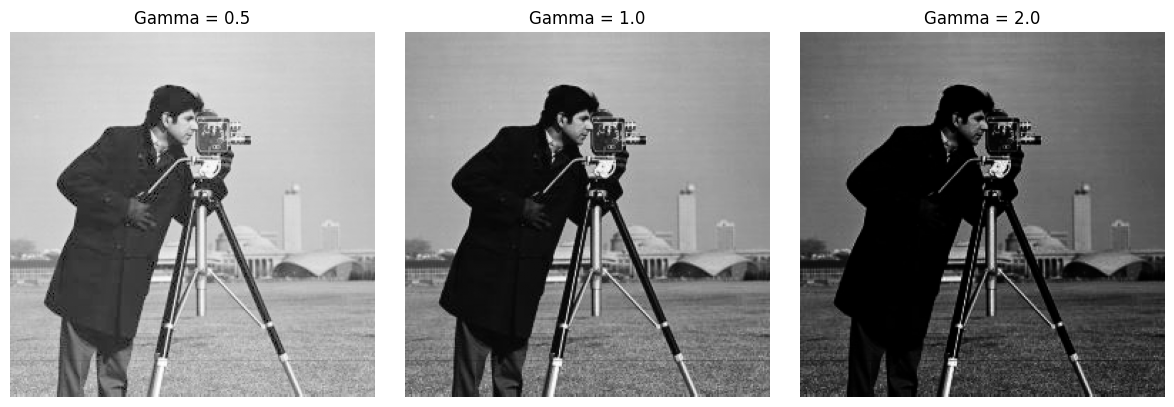

In [26]:
# Compare different gamma values
gammas = [0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(gammas), figsize=(12, 4))
for ax, g in zip(axes, gammas):
    result = 255 * np.power(np.array(image, dtype=np.float32) / 255.0, g)
    result = np.clip(result, 0, 255).astype(np.uint8)
    ax.imshow(result, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Gamma = {g}")
    ax.axis("off")
plt.tight_layout()
plt.show()
